<a href="https://colab.research.google.com/github/mobiledeveloper01/YorubaNumeralTranslatorRuleBased/blob/main/YorubaNumeralTranslator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import functools
import re
import unicodedata

In [ ]:
# @title
'''
lexical_atom=['ookan','eeji','eeta', 'eerin', 'aarun', 'eefa', 'eeje', 'eejo',
                    'esan', 'eewa', 'ogun', 'ogbon', 'igba', 'oodunrun', 'irinwo',
                    'egbaa', 'oke kan']
replacer = [('oke','20000'),('lona',' * '),('eedegbaaji', '3000'), ('eedegbaata', '5000'), ('eedegbaarin', '7000'),
            ('eedegbaarun', '9000'), ('eedegbaafa', '11000'), ('eedegbaaje', '13000'), ('eedegbaajo', '15000'),
            ('eedegbaasan', '17000'), ('eedegbaawa', '19000'), ('eedegbeta', '500'), ('eedegberin', '700'),
            ('eedegberun', '900'), ('eedegbefa', '1100'), ('eedegbeje', '1300'), ('eedegbejo', '1500'),
            ('eedegbesan', '1700'), ('eedegbewa', '1900'),('aadota', '50'), ('aadorin', '70'), ('aadorun', '90'),
             ('aadofa', '110'), ('aadoje', '130'), ('aadojo', '150'), ('aadosan', '170'), ('aadowa', '190'),
            ('egbaa','2000 * '),('egbe','200 * '),('egb(aa)','2000'),('egb(aa','2000 * ('), ('egb','200 * '),  ('aad','10 - '),('eed2000','1000 - 2000'),
             ('eed200','100 - 200'),
            ('okoo','20'),('oji','40'),('ota','60'),('orin','80'),
            ('oodunrun','300'),('odunrun','300'),
            ('irinwo','400'),('igba','200'),('ogbon','30'), ('ogo','20 * '),
            ('ogun','20'),('mokanla','11'),('mejila','12'),('metala','13'),('merinla','14'),
            ('meeedogun','15'),('meedogun','15'),('marundinlogun','15'),('merindinlogun','16'),
            ('metadinlogun','17'),('mejidinlogun','18'),('mokandinlogun','19'),('okandinlogun','19'),
            ('okanla','11'),('ejila','12'),('etala','13'),('erinla','14'),('etadinlogun','17'),('ejidinlogun','18'),
            ('marun','5'),('merin','4'),('meta','3'),('meji','2'),
            ('arun','5'),('erin','4'),('eta','3'),('eji','2'),('okan','1'),

            ('wa','10'),('san','9'),('jo','8'),('je','7'),('fa','6'),
            ('run','5'),('rin','4'),('ta','3'),('ji','2'),('kan','1'),
            ('o le ni','+'),('o le',' + '),('le ni',' + '),('lel',' + '),('le',' + '),('o din ni',' - '),
            ('o din',' - '),('din ni',' - '),('dinl',' - '),('din',' - '),
            ]

import re

def evaluate_expression(expr: str) -> float:
    """
    Evaluate an arithmetic expression with +, -, *, and parentheses.
    Supports integers and floating-point numbers.
    Rules:
      - Multiplication has higher precedence than addition/subtraction.
      - Addition and subtraction are right-associative.
      - Subtraction returns the absolute value of the difference.
      - Parentheses are evaluated first.
    Returns a float.
    """
    # ---------- Tokenization ----------
    tokens = []
    i = 0
    n = len(expr)
    while i < n:
        ch = expr[i]
        if ch.isspace():
            i += 1
            continue
        # Match a number: integer or decimal
        if ch.isdigit() or ch == '.':
            j = i
            # Allow digits and at most one decimal point
            dot_seen = False
            while j < n and (expr[j].isdigit() or expr[j] == '.'):
                if expr[j] == '.':
                    if dot_seen:
                        break
                    dot_seen = True
                j += 1
            num_str = expr[i:j]
            # Convert to float; integers become floats as well
            tokens.append(('num', float(num_str)))
            i = j
            continue
        if ch in '()+-*':
            tokens.append(('op', ch))
            i += 1
        else:
            raise ValueError(f"Unexpected character '{ch}' at position {i}")

    # ---------- Operator precedence and associativity ----------
    precedence = {'+': 1, '-': 1, '*': 2}
    associativity = {'+': 'L', '-': 'L', '*': 'L'}  # R = right, L = left

    # ---------- Shunting-yard to produce RPN ----------
    output = []        # RPN tokens (numbers and operators)
    op_stack = []      # operator stack

    for token in tokens:
        if token[0] == 'num':
            output.append(token[1])
        else:  # operator or parenthesis
            op = token[1]
            if op == '(':
                op_stack.append(op)
            elif op == ')':
                # pop until '('
                while op_stack and op_stack[-1] != '(':
                    output.append(op_stack.pop())
                if not op_stack or op_stack[-1] != '(':
                    raise ValueError("Mismatched parentheses")
                op_stack.pop()  # discard '('
            else:  # operator + - *
                while (op_stack and op_stack[-1] != '(' and
                       (precedence[op_stack[-1]] > precedence[op] or
                        (precedence[op_stack[-1]] == precedence[op] and associativity[op] == 'L'))):
                    output.append(op_stack.pop())
                op_stack.append(op)

    # pop remaining operators
    while op_stack:
        top = op_stack.pop()
        if top == '(':
            raise ValueError("Mismatched parentheses")
        output.append(top)

    # ---------- Evaluate RPN ----------
    eval_stack = []
    for item in output:
        if isinstance(item, float):
            eval_stack.append(item)
        else:  # operator
            b = eval_stack.pop()
            a = eval_stack.pop()
            if item == '+':
                res = a + b
            elif item == '-':
                res = abs(a - b)      # absolute difference (float)
            elif item == '*':
                res = a * b
            else:
                raise ValueError(f"Unknown operator {item}")
            eval_stack.append(res)

    if len(eval_stack) != 1:
        raise ValueError("Invalid expression")
    return eval_stack[0]


def parenthesize_hyphenated(text):
    if 'lona-' in text:
        idx = text.index('lona-')
        text = text[:idx + 5] + parenthesize_hyphenated(text[idx+5:])
    words = text.split()
    result = []
    for word in words:
        if '-' in word:
            result.append(f"({word})")
        else:
            result.append(word)
    result = ' '.join(result)

    return result

def wrap_non_lexical_words(lexical_atom, text):
    words = text.split()
    result = []
    for word in words:
        if word not in lexical_atom and len(word) > 9:
            result.append(f"({word})")
        else:
            result.append(word)
    return " ".join(result)

def reorder_subtraction(match):
    a = int(match.group(1))
    b = int(match.group(2))
    # Ensure larger number is on the left
    if a >= b:
        return f"{a} - {b}"
    else:
        return f"{b} - {a}"
def convert_text_to_digit(t):
    nfd = unicodedata.normalize('NFD', t.lower())
    text = ''.join(c for c in nfd if not unicodedata.combining(c))

    text = parenthesize_hyphenated(text)

    text = text.replace('-',' ')
    text = wrap_non_lexical_words(lexical_atom, text)

    pattern=r'\b(egb)(\S+)'
    text = re.sub(pattern,r'\1(\2)',text)


    pattern = r"(egb)(\w+)"
    text = re.sub(pattern, r"\1(\2)", text)

    pattern = r"(\b\w+)\s+abo"
    text = re.sub(pattern, r"(\1 + 0.5)", text)


    temp = text.replace('-', ' ')
    for key, value in replacer:
        temp = temp.replace(key, value)

    temp = re.sub(r'[^0-9+\-*().]', ' ', temp) # remove all characters that are not digit or arithmetic operator from temp
    temp = re.sub(r'(\d+)\s+(\d+)', r'\1 * \2', temp)# if there are two digits separated by space, insert *


    pattern = r"(\b\d+)\s+(\([^)]*\))|(\([^)]*\))\s+(\b\d+)"
    temp = re.sub(pattern, r"\1\3 * \2\4", temp)

    try:
        result = evaluate_expression(temp)
        return int(result)

    except Exception as e:
        return 0
'''

In [ ]:

lexical_atom=['ookan','eeji','eeta', 'eerin', 'aarun', 'eefa', 'eeje', 'eejo',
                    'esan', 'eewa', 'ogun', 'ogbon', 'igba', 'oodunrun', 'irinwo',
                    'egbaa', 'oke kan']
wholedigit = [('oke','20000'),('ona','*'),('eedegbaaji', '3000'), ('eedegbaata', '5000'), ('eedegbaarin', '7000'),
            ('eedegbaarun', '9000'), ('eedegbaafa', '11000'), ('eedegbaaje', '13000'), ('eedegbaajo', '15000'),
            ('eedegbaasan', '17000'), ('eedegbaawa', '19000'), ('egbaaji', '4000'), ('egbaata', '6000'), ('egbaarin', '8000'),
            ('egbaarun', '10000'), ('egbaafa', '12000'), ('egbaaje', '14000'), ('egbaajo', '16000'),
            ('egbaasan', '18000'), ('egbaawa', '20000'),('eedegbeta', '500'), ('eedegberin', '700'),
            ('eedegberun', '900'), ('eedegbefa', '1100'), ('eedegbeje', '1300'), ('eedegbejo', '1500'),
            ('eedegbesan', '1700'), ('eedegbewa', '1900'),('egbeta', '600'), ('egberin', '800'),
            ('egberun', '1000'), ('egbefa', '1200'), ('egbeje', '1400'), ('egbejo', '1600'),
            ('egbesan', '1800'), ('egbewa', '2000'),('aadota', '50'), ('aadorin', '70'), ('aadorun', '90'),
             ('aadofa', '110'), ('aadoje', '130'), ('aadojo', '150'), ('aadosan', '170'), ('aadowa', '190'),
             ('ogota', '60'), ('ogorin', '80'), ('ogorun', '100'),
             ('ogofa', '120'), ('ogoje', '140'), ('ogojo', '160'), ('ogosan', '180')]
replacer = [
            ('egbaa','2000 * '),('egbe','200 * '),('egb(aa)','2000'),('egb(aa','2000 * ('), ('egb','200 * '),  ('aad','10 - '),('eed2000','1000 - 2000'),
             ('eed200','100 - 200'),('irinwo','400'),('igba','200'),('ogbon','30'), ('ogo','20 * '),
            ('okoo','20'),('oji','40'),('ota','60'),('orin','80'),
            ('oodunrun','300'),('odunrun','300'),
            ('ogun','20'),('mokanla','11'),('mejila','12'),('metala','13'),('merinla','14'),
            ('meeedogun','15'),('meedogun','15'),('marundinlogun','15'),('merindinlogun','16'),
            ('metadinlogun','17'),('mejidinlogun','18'),('mokandinlogun','19'),('okandinlogun','19'),
            ('okanla','11'),('ejila','12'),('etala','13'),('erinla','14'),('etadinlogun','17'),('ejidinlogun','18'),
            ('marun','5'),('merin','4'),('meta','3'),('meji','2'),
            ('arun','5'),('erin','4'),('eta','3'),('eji','2'),('okan','1'),

            ('wa','10'),('san','9'),('jo','8'),('je','7'),('fa','6'),
            ('run','5'),('rin','4'),('ta','3'),('ji','2'),('kan','1'),
            ('o le ni','+'),('o le',' + '),('le ni',' + '),('lel',' + '),('le',' + '),('o din ni',' - '),
            ('o din',' - '),('din ni',' - '),('dinl',' - '),('din',' - '),
            ]
def evaluate_expression(expr: str) -> float:
    """
    Evaluate an arithmetic expression with +, -, *, and parentheses.
    Supports integers and floating-point numbers.
    Rules:
      - Multiplication has higher precedence than addition/subtraction.
      - Addition and subtraction are right-associative.
      - Subtraction returns the absolute value of the difference.
      - Parentheses are evaluated first.
    Returns a float.
    """
    # ---------- Tokenization ----------
    tokens = []
    i = 0
    n = len(expr)
    while i < n:
        ch = expr[i]
        if ch.isspace():
            i += 1
            continue
        # Match a number: integer or decimal
        if ch.isdigit() or ch == '.':
            j = i
            # Allow digits and at most one decimal point
            dot_seen = False
            while j < n and (expr[j].isdigit() or expr[j] == '.'):
                if expr[j] == '.':
                    if dot_seen:
                        break
                    dot_seen = True
                j += 1
            num_str = expr[i:j]
            # Convert to float; integers become floats as well
            tokens.append(('num', float(num_str)))
            i = j
            continue
        if ch in '()+-*':
            tokens.append(('op', ch))
            i += 1
        else:
            raise ValueError(f"Unexpected character '{ch}' at position {i}")

    # Operator precedence and associativity
    precedence = {'+': 1, '-': 1, '*': 2}
    associativity = {'+': 'L', '-': 'L', '*': 'L'}  # R = right, L = left

    #Shunting-yard to produce RPN
    output = []        # RPN tokens
    op_stack = []

    for token in tokens:
        if token[0] == 'num':
            output.append(token[1])
        else:  # operator or parenthesis
            op = token[1]
            if op == '(':
                op_stack.append(op)
            elif op == ')':
                # pop until '('
                while op_stack and op_stack[-1] != '(':
                    output.append(op_stack.pop())
                if not op_stack or op_stack[-1] != '(':
                    raise ValueError("Mismatched parentheses")
                op_stack.pop()
            else:  # operator + - *
                while (op_stack and op_stack[-1] != '(' and
                       (precedence[op_stack[-1]] > precedence[op] or
                        (precedence[op_stack[-1]] == precedence[op] and associativity[op] == 'L'))):
                    output.append(op_stack.pop())
                op_stack.append(op)

    # pop remaining operators
    while op_stack:
        top = op_stack.pop()
        if top == '(':
            raise ValueError("Mismatched parentheses")
        output.append(top)

    # Evaluate RPN
    eval_stack = []
    for item in output:
        if isinstance(item, float):
            eval_stack.append(item)
        else:  # operator
            b = eval_stack.pop()
            a = eval_stack.pop()
            if item == '+':
                res = a + b
            elif item == '-':
                res = abs(a - b)      # absolute difference (float)
            elif item == '*':
                res = a * b
            else:
                raise ValueError(f"Unknown operator {item}")
            eval_stack.append(res)

    if len(eval_stack) != 1:
        raise ValueError("Invalid expression")
    return eval_stack[0]


def parenthesize_hyphenated(text):
    words = text.split()
    result = []
    for word in words:
        if '-' in word:
            result.append(f"({word})")
        else:
            result.append(word)
    result = ' '.join(result)
    mstr = result.replace('-',' ')
    return mstr

def wrap_non_lexical_words(lexical_atom, text):
    words = text.split()
    result = []
    for word in words:
        if word not in lexical_atom and len(word) > 9:
            result.append(f"({word})")
        else:
            result.append(word)
    return " ".join(result)

def reorder_subtraction(match):
    a = int(match.group(1))
    b = int(match.group(2))
    # Ensure larger number is on the left
    if a >= b:
        return f"{a} - {b}"
    else:
        return f"{b} - {a}"

def prepare_expression_for_evaluation(temp):
    """
    Prepare a Yoruba numeral expression for evaluation by converting
    implicit multiplication to explicit operators.
    """
    # Pass 1: Number then parentheses
    temp = re.sub(r"(\b\d+)\s+(\([^)]*\))", r"\1 * \2", temp)

    # Pass 2: Parentheses then number (handles (2000) 3)
    temp = re.sub(r"(\([^)]*\))\s+(\b\d+)", r"\1 * \2", temp)

    # Handle cases without spaces
    temp = re.sub(r"(\b\d+)(\([^)]*\))", r"\1 * \2", temp)
    temp = re.sub(r"(\([^)]*\))(\b\d+)", r"\1 * \2", temp)

    return temp


def text_to_digit(t):
    #print("Original text:", t)
    nfd = unicodedata.normalize('NFD', t.lower())
    text = ''.join(c for c in nfd if not unicodedata.combining(c))

    text = parenthesize_hyphenated(text)
    #print('Parentesized',text)
    text = wrap_non_lexical_words(lexical_atom, text)

    for key, value in wholedigit:
        text = text.replace(key, value)

    pattern=r'\b(egb)(\S+)'
    text = re.sub(pattern,r'\1(\2)',text)
    #print("Stage 1:",text)

    pattern = r"(egb)(\w+)"
    text = re.sub(pattern, r"\1(\2)", text)
    #print("Stage 2:",text)

    pattern = r"(\b\w+)\s+abo"
    text = re.sub(pattern, r"(\1 + 0.5)", text)


    temp = text.replace('-', ' ')
    for key, value in replacer:
        temp = temp.replace(key, value)

    #print("Stage 3:",temp)
    temp = re.sub(r'[^0-9+\-*().]', ' ', temp) # remove all characters that are not digit or arithmetic operator from temp
    temp = re.sub(r'(\d+)\s+(\d+)', r'\1 * \2', temp)# if there are two digits separated by space, insert *
    #print('Stage 4:', temp)

    #pattern = r"(\b\d+)\s+(\([^)]*\))|(\([^)]*\))\s+(\b\d+)"
    temp = prepare_expression_for_evaluation(temp)
    #print('Stage 5:', temp)

    try:
        result = evaluate_expression(temp)
        return int(result)
    except Exception as e:
        return 0

In [ ]:
building_blocks = {1:'oókan', 2:'éjì', 3:'ẹ́ta', 4:'ẹ́rin', 5:'árùn', 6:'ẹ́fà', 7:'éje', 8:'ẹ́jọ',
                    9:'ẹ́sàn', 10:'ẹ́wà', 20:'ogún', 30:'ọgbọ̀n', 200:'igba', 300:'ọ̀ọ́dúnrún', 400:'irínwó',
                    2000:'ẹgbàá', 20000:'ọ̀kẹ́ kan'}
suffixes = {2:'jì', 3:'ta', 4:'rin', 5:'rùn', 6:'fà', 7:'je', 8:'jọ', 9:'sàn', 10:'wà'}
prefixes_base = {20:'ọgọ́', 200:'ẹgbẹ̀', 2000:'ẹgbàá'}
prefixes_units = {1:'ọ̀kan', 2:'èjì', 3:'ẹ̀ta', 4:'ẹ̀rin', 5:'àrún', 6:'ẹ̀fà', 7:'èje', 8:'ẹ̀jọ', 9:'ẹ̀sàn', 10:'ẹ̀wà'}
prefixes_tens = {20:'okòó', 40:'òjì', 60:'ọ̀tà', 80:'ọ̀rìn'}
prefixes_sub = {-10:'àádọ́', -100:'ẹ̀éd', -1000:'ẹ̀ẹ́d'}
conjunctions = {'sub':'dín', 'add':'lé'}

def text2int(textnum, numwords = {}):
    if not numwords:
        units = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight",
                 "nine", "ten", "eleven", "twelve", "thirteen", "fourteen", "fifteen",
                 "sixteen", "seventeen", "eighteen", "nineteen"]
        tens = ["","","twenty","thirty","fourty","fifty","sixty","seventy","eighty","ninety"]
        scales =["hundred", "thousand", "million"]
        numwords["and"] = (1,0)
        for idx, word in enumerate(units): numwords[word]=(1, idx)
        for idx, word in enumerate(tens): numwords[word]=(1,idx*10)
        for idx, word in enumerate(scales): numwords[word]=(10**(idx*3 or 2), 0)
    current = result = 0
    for word in textnum.replace("-", " ").lower().split():
        if word not in numwords:
            raise Exception("Illegal word: " + word)
        scale, increment = numwords[word]
        current = current * scale + increment
        if scale > 100:
            result += current
            current = 0
    return result + current

def get_input():
    while True:
        num = input('Enter the number to translate: ')
        try:
            num = int(num)
        except ValueError:
            num = text2int(num)
            if str(num).isnumeric():
                return num
            else:
                continue
        else:
            return num

@functools.lru_cache(maxsize=None)
def get_translation(x, cluster=0):
    trans_parts = []
    count_20000 = closest_1000 = closest_100 = closest_10 = sub20 = 0
    join_thous = join_hunds = join_tens = join_sub20 = tens_mode = ""
    trans_20000 = ""
    remain = x
    if remain in building_blocks:
        return building_blocks[remain]

    if remain > 20000:
        count_20000 = remain//20000
        trans_20000 = get_translation(count_20000, cluster=1)
        remain = remain % 20000
    #print('Tracker:',count_20000, remain)
    if remain > 2000:
        floor = (remain//1000)*1000
        ceil = (remain//1000 + 1)*1000
        if abs(remain - floor) <= abs(remain - ceil):
            closest_1000 = floor//1000
            join_thous = "ó lé ní"
        else:
            closest_1000 = ceil//1000
            join_thous = "ó dín"
        remain = abs(remain - closest_1000 * 1000)
    #print('Tracker:', join_thous, closest_1000, remain)
    if remain > 200:
        tens_mode = "high"
        closest_100 = remain//100
        join_hunds = "léní"
        remain = remain - closest_100 * 100
    #print('Tracker:', join_hunds, closest_100, remain)
    if remain >= 20:
        if tens_mode == "high":
            floor = (remain//20)*20
            ceil = (remain//20 + 1)*20
            if abs(remain - floor) <= abs(remain - ceil):
                closest_10 = floor//20
                if closest_10 == 5:
                    closest_10 = 4
                    join_tens = "ó dín"
                else:
                    join_tens = "ó lé"

            else:
                closest_10 = int(ceil/20)
                if closest_10 == 5:
                    closest_10 = 4
                    join_tens = "ó lé"
                else:
                    join_tens = "ó dín"
            remain = abs(remain - closest_10 * 20)
        else:
            floor = (remain//10)*10
            ceil = (remain//10 + 1)*10
            if abs(remain - floor) < abs(remain - ceil):
                closest_10 = int(floor/10)
                join_tens = "lél"
            else:
                closest_10 = int(ceil/10)
                join_tens = "dínl"
            remain = abs(remain - closest_10 * 10)
    elif remain < 20 and remain > 0 and tens_mode == "high":
        join_tens = "ó lé"
    #print('Tracker:', join_tens, closest_10, remain)

    if remain > 10:
        if abs(remain - 20) <= abs(remain - 10):
            join_sub20 = "dín"
            sub20 = 20 - remain
        else:
            join_sub20 = "lá"
            sub20 = remain - 10
    #print('Tracker:', join_sub20, sub20, remain)
    #print(closest_1000, closest_100, closest_10, sub20)

    #----------------------------------------------------------------------------

    trans1000 = trans100 = trans10 = trans1 = ""

    if closest_1000 != 0:
        if closest_1000 * 1000 in building_blocks:
            trans1000 = building_blocks[closest_1000 * 1000]
        else:
            if closest_1000 % 2 != 0:
                trans1000 += "ẹ̀ẹ́d"
                trans1000 += prefixes_base[2000]
                trans1000 += suffixes[(closest_1000 + 1)/2]
            else:
                trans1000 += prefixes_base[2000]
                trans1000 += suffixes[closest_1000/2]

    if closest_100 != 0:
        if closest_100 * 100 in building_blocks:
            trans100 = building_blocks[closest_100 * 100]
        else:
            if closest_100 % 2 != 0:
                trans100 += "ẹ̀ẹ́d"
                trans100 += prefixes_base[200]
                trans100 += suffixes[(closest_100 + 1)/2]
            else:
                trans100 += prefixes_base[200]
                trans100 += suffixes[closest_100/2]

    if closest_10 != 0:
        if tens_mode == "high":
            trans10 = prefixes_tens[closest_10 * 20]
        else:
            if closest_10 * 10 in building_blocks:
                trans10 = building_blocks[closest_10 * 10]
            else:
                if closest_10 % 2 != 0:
                    trans10 += "àádọ́"
                    trans10 += suffixes[(closest_10 + 1)/2]
                else:
                    trans10 += prefixes_base[20]
                    trans10 += suffixes[closest_10/2]
    #print('Final tracker', join_sub20,remain,sub20)
    if sub20 != 0 or remain != 0:
        if sub20 != 0:
            trans1 += prefixes_units[sub20] + join_sub20
            if join_sub20 == "dín":
                trans1 += 'lógún'

        else:
            if tens_mode == "high":
                trans1 = building_blocks[remain]
            else:
                # add a try except block here to catch any potential key errors
                try:
                    trans1 = prefixes_units[remain]
                except KeyError:
                    return ""

    #print('1000:', trans1000, '100:', trans100, '10:', trans10, '1:', trans1)


    #-----------------------------------------------------------------
    if trans_20000 != "":
        trans_parts.append("ọ̀kẹ́ ")
        if count_20000 == 1:
            trans_parts.append("kan")
        elif (count_20000 !=10 and count_20000%10==0) or count_20000>200:
            trans_parts.append("lọ́nà " + trans_20000)
        else:
            trans_parts.append("m" + trans_20000)
        if trans1000 != "" or trans100 != "" or trans10 != "" or trans1 != "":
            trans_parts.append(" ó lé ")
    #print('Tracker1:', trans)
    if trans1000 != "":
        trans_parts.append(trans1000)
        if trans100 != "" or trans10 != "" or trans1 != "":
            trans_parts.append(" " + join_thous + " ")
    #print('Tracker2:', trans)
    if trans100 != "":
        if trans10 != "":
            if trans1 != "":
                if join_tens =="ó lé": join_tens = 'léní'
                if join_tens =="ó dín": join_tens = 'dínní'
                trans_parts.append(trans1 + join_tens + trans10 + join_hunds + trans100)
                trans1=""
            else:
                trans_parts.append(trans10 + join_hunds + trans100) #ojilenioodunrun, okoolenirinwo etc
        else:
            if trans1 != "":
                if join_tens =="ó lé": join_tens = 'léní'
                if join_tens =="ó dín": join_tens = 'dínní'
                trans_parts.append(trans1 + join_tens + trans100)
                trans1=""
            else: trans_parts.append(trans100)
        if trans1 != "":
            trans_parts.append(" " + join_tens + " " + trans1)
    if trans10 != "" and trans1 != "" and trans100 == "":
        trans_parts.append(trans1 + join_tens + trans10)
    if trans10 == "" and trans1 != "" and trans100 == "":
        trans_parts.append(trans1)
    if trans10 != "" and trans1 == "" and trans100 == "":
        trans_parts.append(trans10)

    trans = "".join(trans_parts) # Join parts at the end

    if cluster == 1:
        trans = trans.replace(" ", "-")
    return trans

def convert_to_yoruba(num):
    if num in building_blocks:
        return building_blocks[num]
    else:
        return get_translation(num)

In [ ]:
# @title
import time
import multiprocessing

def process_range(start_num, end_num):
    """Processes a range of numbers and returns a list of failed translations."""
    local_failed = []
    for i in range(start_num, end_num):
        text = convert_to_yoruba(i);
        num = text_to_digit(text);
        if int(num) != i:
            local_failed.append(f"Failed for {i}: got {num} from text '{text}'\n")
    return local_failed

start_time = time.time()

# User-defined bounds
LOWER_BOUND = 302000000
UPPER_BOUND = 303000000 # Up to 399980000

MAX_NUMBER = UPPER_BOUND # Use the upper bound as the maximum number
NUM_PROCESSES = multiprocessing.cpu_count() # Use all available CPU cores
CHUNK_SIZE = (MAX_NUMBER - LOWER_BOUND) // NUM_PROCESSES

# Create a list of (start, end) tuples for each process
ranges = []
for i in range(NUM_PROCESSES):
    start_num = LOWER_BOUND + i * CHUNK_SIZE
    end_num = min(MAX_NUMBER, LOWER_BOUND + (i + 1) * CHUNK_SIZE)
    if start_num < MAX_NUMBER:
        ranges.append((start_num, end_num))

# Handle any remaining numbers in the last chunk
if ranges and ranges[-1][1] < MAX_NUMBER:
    ranges[-1] = (ranges[-1][0], MAX_NUMBER)

failed = []
with multiprocessing.Pool(processes=NUM_PROCESSES) as pool:
    # Use starmap to pass multiple arguments to process_range
    results = pool.starmap(process_range, ranges)
    for res_list in results:
        failed.extend(res_list)

end_time = time.time()
print(f"Total time taken with {NUM_PROCESSES} processes: {end_time - start_time:.2f} seconds\n")

# Write the failed translations to a file
with open('failed_translations.txt', 'w') as f:
    for entry in failed:
        f.write(entry)

print(f"Failed translations (if any) written to failed_translations.txt")
print(f"Number of failed translations: {len(failed)}")

Total time taken with 2 processes: 58.82 seconds

Failed translations (if any) written to failed_translations.txt
Number of failed translations: 0


YORUBA NUMERAL SYSTEM VALIDATION
Testing numbers from 400M to 8T (safe range)

[Step 1] Generating 1,000,000 test numbers...
Generating 1,000,000 numbers between 400,000,000 and 7,999,999,999,999
------------------------------------------------------------
  Stratum 1: 400,000,000 - 1,000,000,000 -> 44,444 samples
  Stratum 2: 1,000,000,000 - 10,000,000,000 -> 44,444 samples
  Stratum 3: 10,000,000,000 - 100,000,000,000 -> 44,444 samples
  Stratum 4: 100,000,000,000 - 500,000,000,000 -> 44,444 samples
  Stratum 5: 500,000,000,000 - 1,000,000,000,000 -> 44,444 samples
  Stratum 6: 1,000,000,000,000 - 2,000,000,000,000 -> 44,444 samples
  Stratum 7: 2,000,000,000,000 - 4,000,000,000,000 -> 44,444 samples
  Stratum 8: 4,000,000,000,000 - 6,000,000,000,000 -> 44,444 samples
  Stratum 9: 6,000,000,000,000 - 7,999,999,999,999 -> 44,444 samples
  Boundary-focused samples: 100,311
    Multiples of 20: 25,000 samples
    Multiples of 200: 25,000 samples
    Multiples of 2000: 25,000 samples
   

/tmp/ipykernel_13552/4059143247.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(magnitude_groups, labels=magnitude_labels, patch_artist=True)


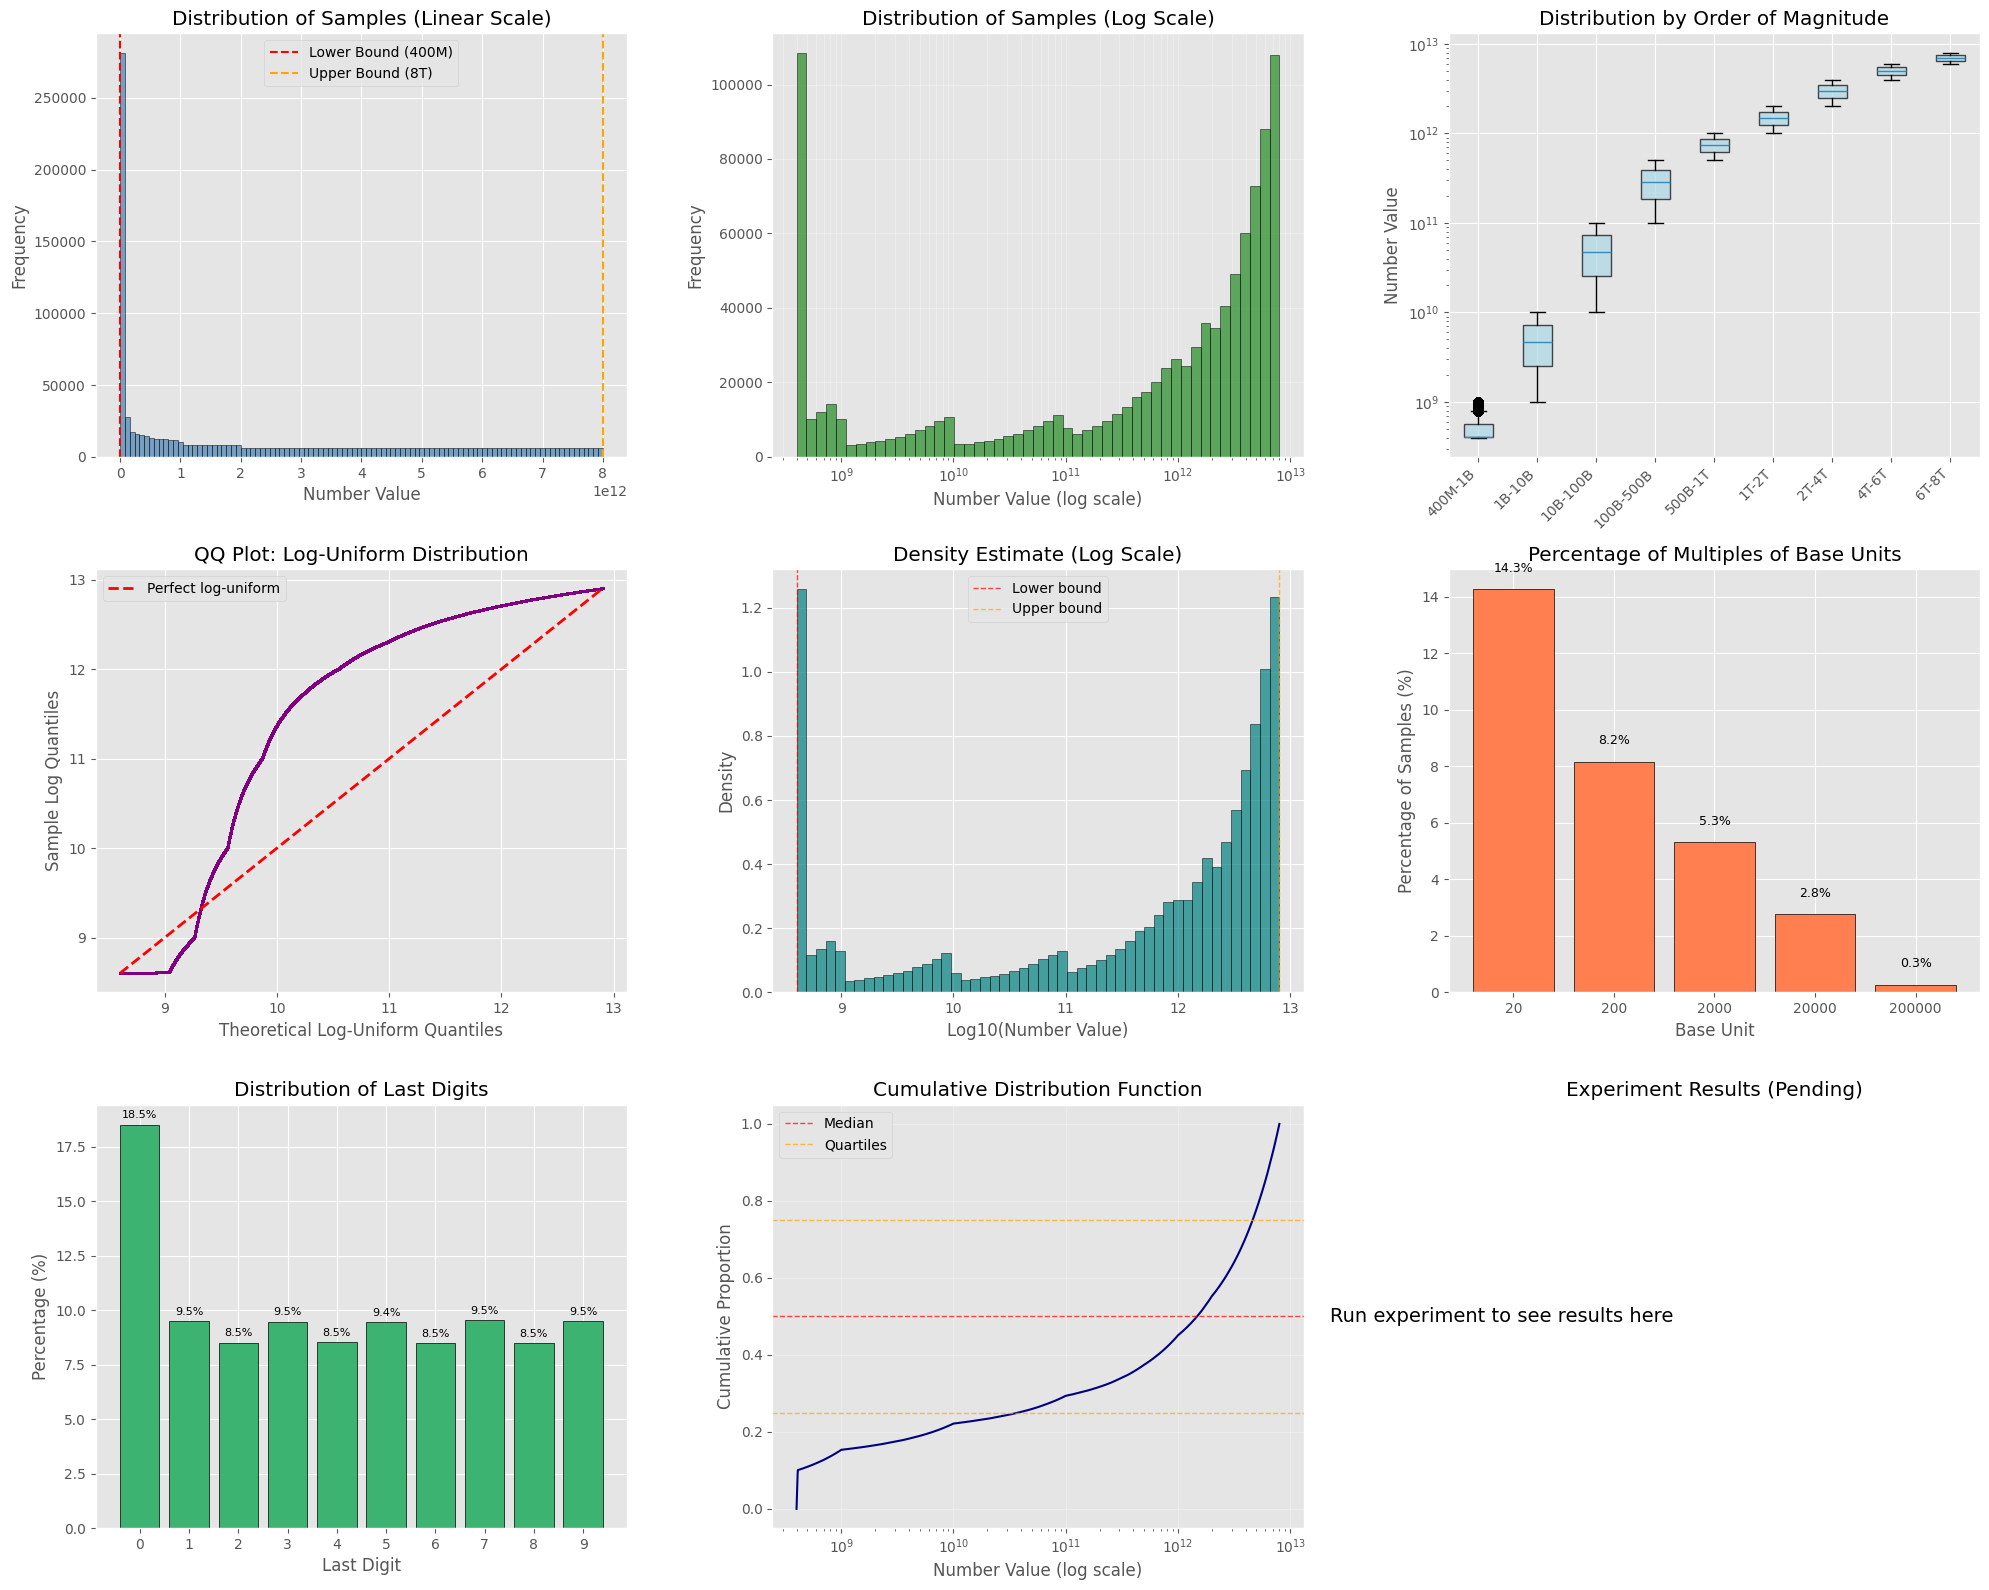


Visualization saved as 'sample_distribution_visualization.png'

[Step 3] Ready to run bidirectional conversion experiment...

RUNNING BIDIRECTIONAL CONVERSION EXPERIMENT
Total numbers to test: 1,000,000
Batch size: 10,000
------------------------------------------------------------
  Progress: 100,000/1,000,000 (10.0%) | Time: 8.7s | Rate: 11435 nums/s
  Progress: 200,000/1,000,000 (20.0%) | Time: 18.6s | Rate: 10737 nums/s
  Progress: 300,000/1,000,000 (30.0%) | Time: 29.6s | Rate: 10142 nums/s
  Progress: 400,000/1,000,000 (40.0%) | Time: 41.0s | Rate: 9748 nums/s
  Progress: 500,000/1,000,000 (50.0%) | Time: 54.7s | Rate: 9146 nums/s
  Progress: 600,000/1,000,000 (60.0%) | Time: 66.5s | Rate: 9018 nums/s
  Progress: 700,000/1,000,000 (70.0%) | Time: 78.5s | Rate: 8914 nums/s
  Progress: 800,000/1,000,000 (80.0%) | Time: 90.2s | Rate: 8869 nums/s
  Progress: 900,000/1,000,000 (90.0%) | Time: 101.7s | Rate: 8847 nums/s
  Progress: 1,000,000/1,000,000 (100.0%) | Time: 114.5s | Rate: 8

/tmp/ipykernel_13552/4059143247.py:321: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(magnitude_groups, labels=magnitude_labels, patch_artist=True)


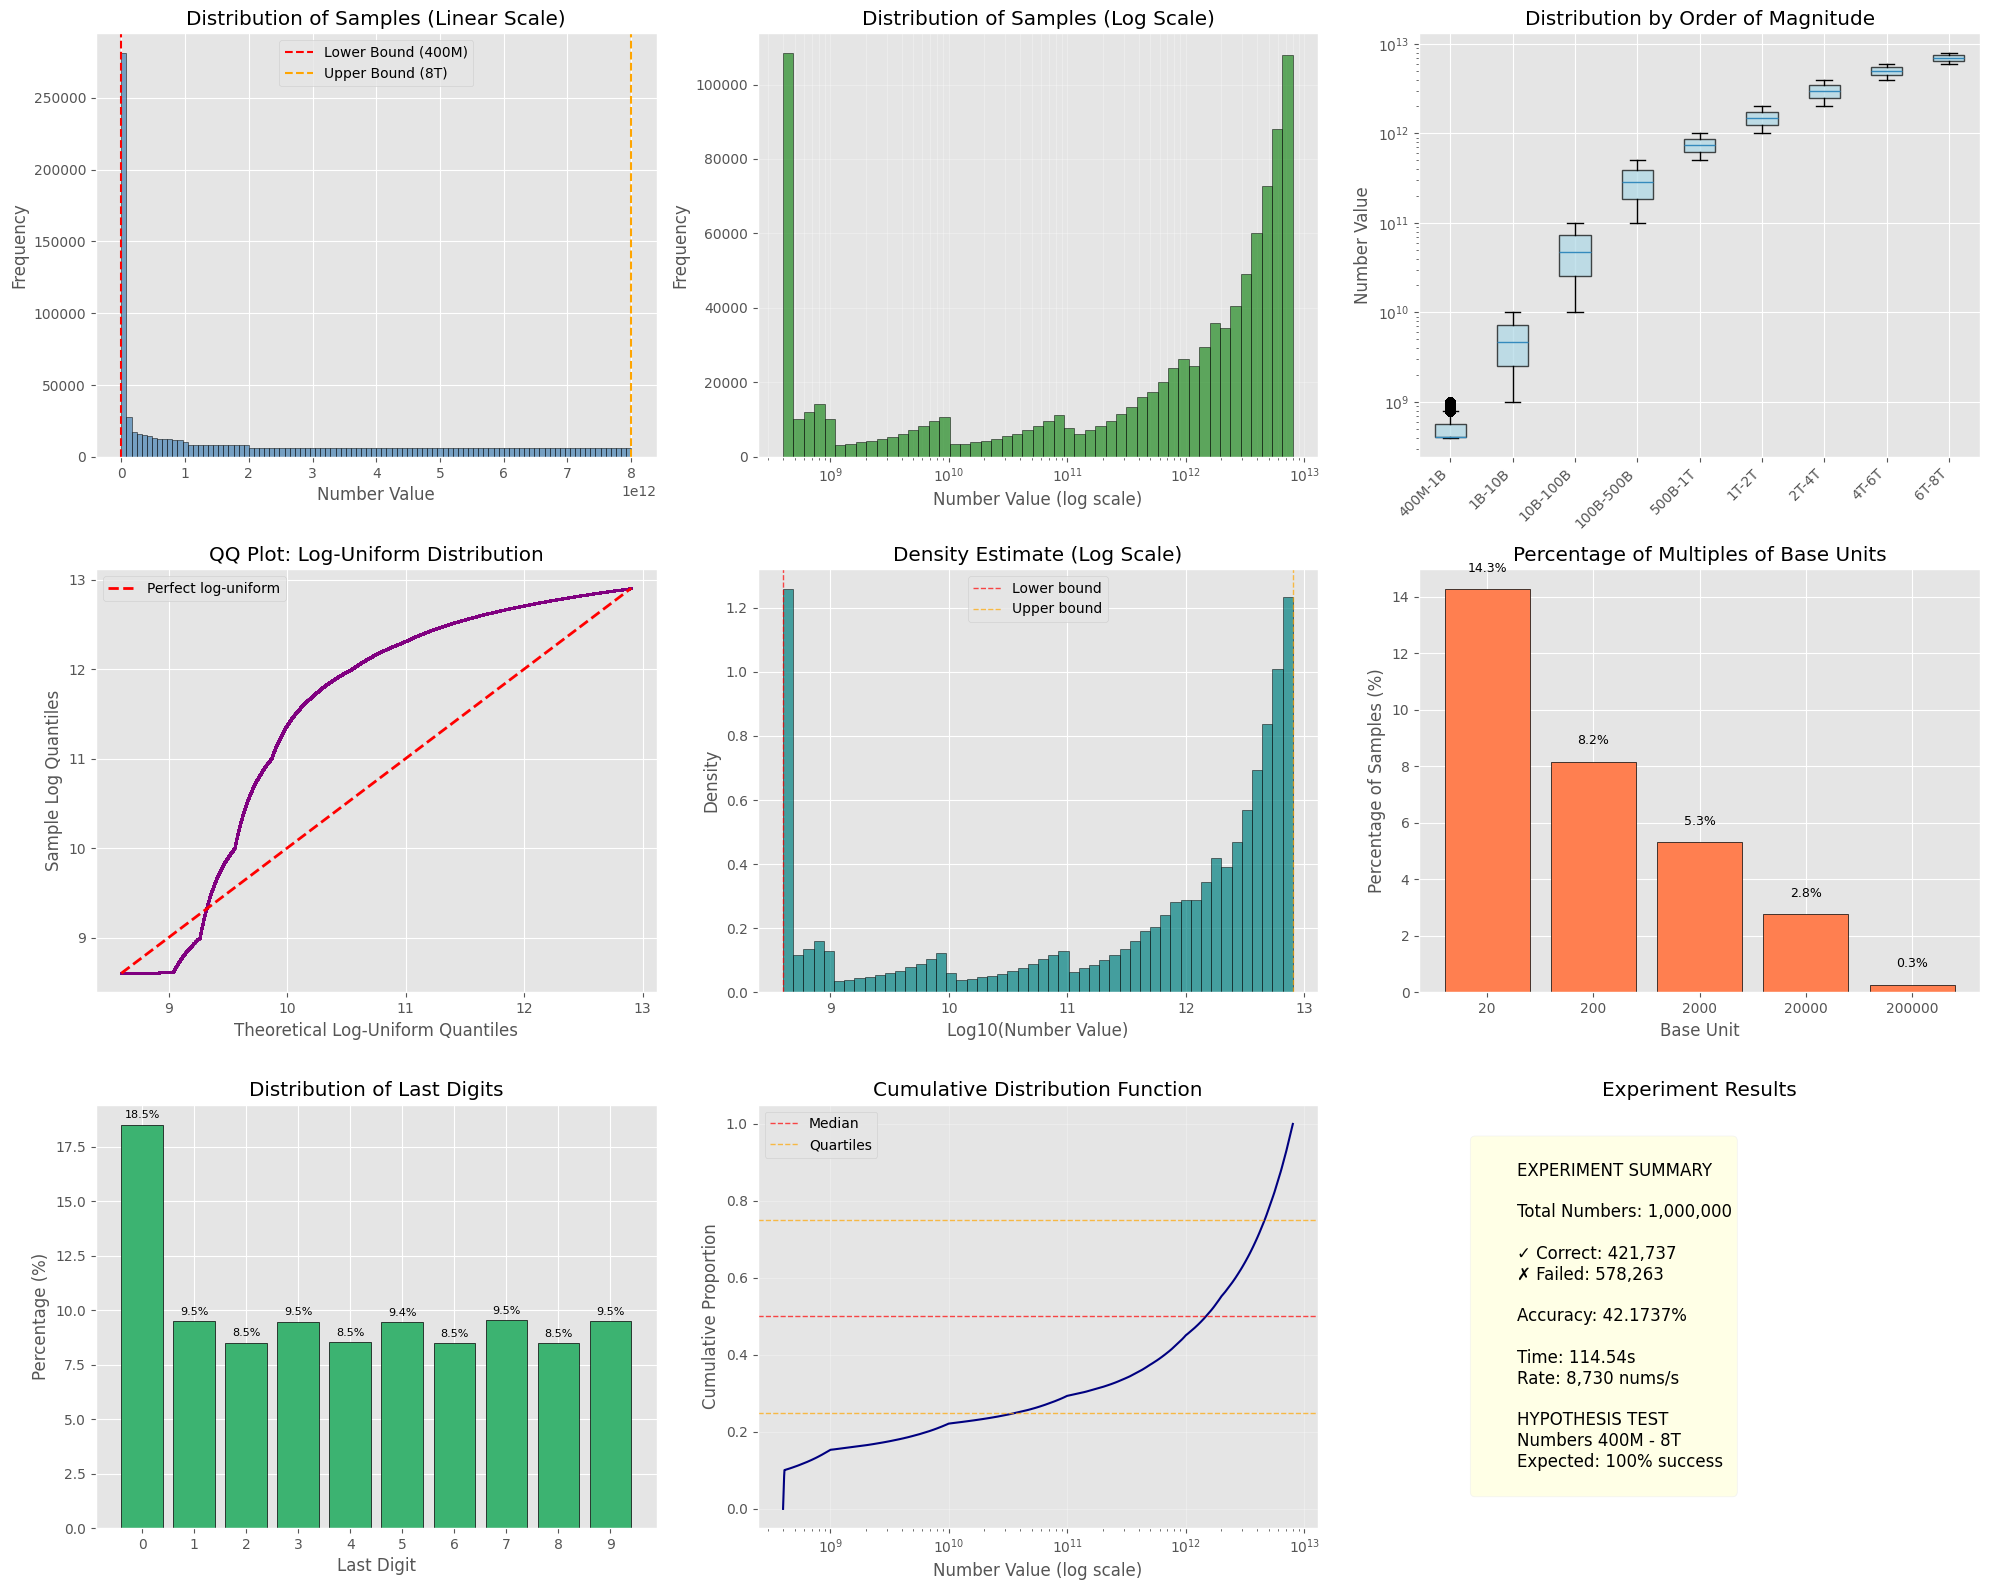


Visualization saved as 'sample_distribution_visualization.png'


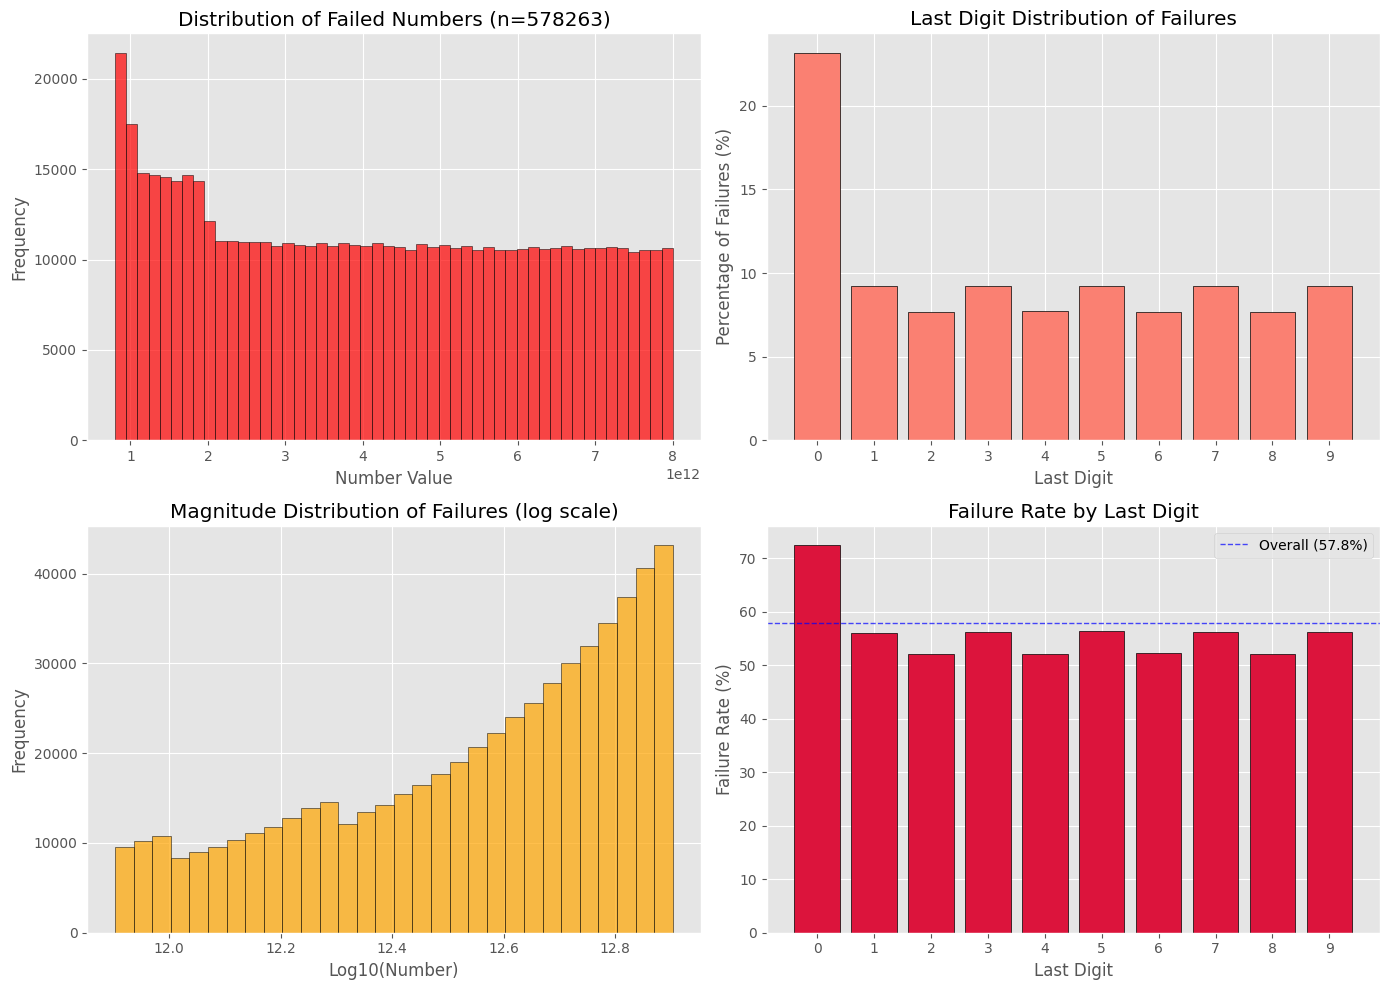


Failure analysis saved as 'failure_analysis.png'
578263

Script completed successfully!


In [ ]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
from collections import Counter

tfailures=[]
# ============================================================================
# MEMORY-EFFICIENT SAMPLE GENERATION
# ============================================================================

def generate_hybrid_sample_for_safe_range(total_samples=1_000_000):
    """
    Generate 1 million numbers between 400,000,000 and 7,999,999,999,999
    using a hybrid sampling strategy.
    MEMORY-EFFICIENT: No large intermediate arrays.
    """
    random.seed(12)

    LOWER_BOUND = 400_000_000
    UPPER_BOUND = 7_999_999_999_999

    samples = []

    print(f"Generating {total_samples:,} numbers between {LOWER_BOUND:,} and {UPPER_BOUND:,}")
    print("-" * 60)

    rng = np.random.default_rng(seed=42)

    # -------------------------------------------------------------------------
    # 1. Stratified log-scale sampling (40% = 400,000 samples)
    # -------------------------------------------------------------------------
    strata_edges = [
        400_000_000,
        1_000_000_000,
        10_000_000_000,
        100_000_000_000,
        500_000_000_000,
        1_000_000_000_000,
        2_000_000_000_000,
        4_000_000_000_000,
        6_000_000_000_000,
        UPPER_BOUND
    ]

    stratified_count = int(0.40 * total_samples)
    samples_per_stratum = stratified_count // (len(strata_edges) - 1)

    for i in range(len(strata_edges) - 1):
        start = strata_edges[i]
        end = strata_edges[i + 1]
        if end > start:
            # Direct random sampling without creating large arrays
            stratum_samples = rng.integers(start, end, size=samples_per_stratum, dtype=np.int64)
            samples.extend(stratum_samples)
            print(f"  Stratum {i+1}: {start:,} - {end:,} -> {samples_per_stratum:,} samples")

    # -------------------------------------------------------------------------
    # 2. Boundary-focused sampling (25% = 250,000 samples)
    # -------------------------------------------------------------------------
    boundary_count = int(0.25 * total_samples)

    critical_boundaries = [
        400_000_000, 400_000_020, 400_000_200, 400_002_000, 400_020_000,
        400_200_000, 402_000_000, 420_000_000, 600_000_000, 800_000_000,
        1_000_000_000, 2_000_000_000, 5_000_000_000, 10_000_000_000,
        20_000_000_000, 50_000_000_000, 100_000_000_000, 200_000_000_000,
        500_000_000_000, 1_000_000_000_000, 2_000_000_000_000, 4_000_000_000_000,
        6_000_000_000_000, 7_999_999_999_000, 7_999_999_999_999
    ]

    boundary_samples = []
    for boundary in critical_boundaries:
        if LOWER_BOUND <= boundary <= UPPER_BOUND:
            for offset in [-100, -50, -20, -10, -5, -1, 0, 1, 5, 10, 20, 50, 100]:
                val = boundary + offset
                if LOWER_BOUND <= val <= UPPER_BOUND:
                    boundary_samples.append(val)

    # Add random samples near lower bound if needed
    if len(boundary_samples) < boundary_count:
        needed = boundary_count - len(boundary_samples)
        # Sample near lower bound (first 10 million)
        sample_max = min(LOWER_BOUND + 10_000_000, UPPER_BOUND)
        additional = rng.integers(LOWER_BOUND, sample_max, size=min(needed, 100_000), dtype=np.int64)
        boundary_samples.extend(additional)

    if len(boundary_samples) > boundary_count:
        boundary_samples = random.sample(boundary_samples, boundary_count)

    samples.extend(boundary_samples)
    print(f"  Boundary-focused samples: {len(boundary_samples):,}")

    # -------------------------------------------------------------------------
    # 3. Structural category sampling (20% = 200,000 samples)
    # -------------------------------------------------------------------------
    structural_count = int(0.20 * total_samples)
    structural_samples = []

    # Sample multiples of base units without creating giant arrays
    base_units = [20, 200, 2000, 20000]

    for base in base_units:
        # Calculate approximate range of multipliers
        min_mult = (LOWER_BOUND + base - 1) // base
        max_mult = UPPER_BOUND // base

        if min_mult <= max_mult:
            # Number of possible multipliers
            num_mults = max_mult - min_mult + 1
            # Sample size for this base (max 25,000 per base to stay within budget)
            sample_size = min(25_000, structural_count // len(base_units), num_mults)

            # Randomly sample multipliers, then multiply by base
            sampled_mults = rng.integers(min_mult, max_mult + 1, size=sample_size, dtype=np.int64)
            sampled_numbers = sampled_mults * base
            structural_samples.extend(sampled_numbers)
            print(f"    Multiples of {base}: {sample_size:,} samples")

    # Add numbers with specific ending patterns (1-29, odd, etc.)
    pattern_samples_needed = structural_count // 4
    patterns = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]

    for _ in range(min(pattern_samples_needed, 50_000)):
        # Generate random number, then adjust last two digits
        num = rng.integers(LOWER_BOUND, UPPER_BOUND, dtype=np.int64)
        pattern = random.choice(patterns)
        num = (num // 100) * 100 + pattern
        if LOWER_BOUND <= num <= UPPER_BOUND:
            structural_samples.append(num)

    if len(structural_samples) > structural_count:
        structural_samples = random.sample(structural_samples, structural_count)

    samples.extend(structural_samples)
    print(f"  Structural category samples: {len(structural_samples):,}")

    # -------------------------------------------------------------------------
    # 4. Latin Hypercube Sampling (10% = 100,000 samples)
    # -------------------------------------------------------------------------
    lhs_count = int(0.10 * total_samples)

    sampler = qmc.LatinHypercube(d=1, seed=42)
    samples_01 = sampler.random(n=lhs_count).flatten()
    log_min = np.log(float(LOWER_BOUND))
    log_max = np.log(float(UPPER_BOUND))
    log_samples = log_min + samples_01 * (log_max - log_min)
    lhs_samples = np.exp(log_samples).astype(np.int64)
    lhs_samples = np.clip(lhs_samples, LOWER_BOUND, UPPER_BOUND)
    samples.extend(lhs_samples)
    print(f"  Latin Hypercube samples: {lhs_count:,}")

    # -------------------------------------------------------------------------
    # 5. Random fill to reach exact count
    # -------------------------------------------------------------------------
    current_count = len(samples)
    if current_count < total_samples:
        needed = total_samples - current_count
        random_samples = rng.integers(LOWER_BOUND, UPPER_BOUND + 1, size=needed, dtype=np.int64)
        samples.extend(random_samples)
        print(f"  Random fill: {needed:,}")

    # Shuffle and deduplicate
    random.shuffle(samples)
    samples = np.array(samples, dtype=np.int64)
    samples = np.unique(samples)

    # If deduplication reduced count, add more random numbers
    if len(samples) < total_samples:
        needed = total_samples - len(samples)
        additional = rng.integers(LOWER_BOUND, UPPER_BOUND + 1, size=needed, dtype=np.int64)
        samples = np.concatenate([samples, additional])
        samples = np.unique(samples)  # Final dedupe

    print("-" * 60)
    print(f"Final sample size: {len(samples):,}")

    return samples[:total_samples]

# ============================================================================
# EXPERIMENT FUNCTION
# ============================================================================

def run_experiment(numbers, batch_size=10000):
    """
    Run bidirectional conversion experiment on the provided numbers.
    """
    print("\n" + "=" * 60)
    print("RUNNING BIDIRECTIONAL CONVERSION EXPERIMENT")
    print("=" * 60)
    print(f"Total numbers to test: {len(numbers):,}")
    print(f"Batch size: {batch_size:,}")
    print("-" * 60)

    start_time = time.time()

    correct_count = 0
    failures = []

    num_batches = (len(numbers) + batch_size - 1) // batch_size

    for batch_idx in range(num_batches):
        batch_start = batch_idx * batch_size
        batch_end = min(batch_start + batch_size, len(numbers))
        batch_numbers = numbers[batch_start:batch_end]

        for num in batch_numbers:
            try:
                yoruba_output = convert_to_yoruba(num)
                reversed_digit = text_to_digit(yoruba_output)

                if reversed_digit == num:
                    correct_count += 1
                else:
                    failures.append({
                        'original': num,
                        'yoruba': yoruba_output,
                        'reversed': reversed_digit
                    })
            except Exception as e:
                failures.append({
                    'original': num,
                    'yoruba': f"ERROR: {str(e)}",
                    'reversed': None
                })

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == num_batches:
            elapsed = time.time() - start_time
            processed = batch_end
            rate = processed / elapsed if elapsed > 0 else 0
            print(f"  Progress: {processed:,}/{len(numbers):,} ({processed/len(numbers)*100:.1f}%) | "
                  f"Time: {elapsed:.1f}s | Rate: {rate:.0f} nums/s")

    end_time = time.time()
    elapsed_time = end_time - start_time

    total = len(numbers)
    accuracy = (correct_count / total * 100) if total > 0 else 0

    print("\n" + "=" * 60)
    print("EXPERIMENT RESULTS")
    print("=" * 60)
    print(f"Total numbers processed: {total:,}")
    print(f"Correct conversions: {correct_count:,}")
    print(f"Failed conversions: {len(failures):,}")
    print(f"Accuracy: {accuracy:.4f}%")
    print(f"Total time: {elapsed_time:.2f} seconds")
    print(f"Processing rate: {total / elapsed_time:,.0f} numbers/second")

    return {
        'correct_count': correct_count,
        'failures': failures,
        'accuracy': accuracy,
        'elapsed_time': elapsed_time,
        'rate': total / elapsed_time
    }


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================
def create_visualizations(samples, experiment_results=None):
    """
    Create comprehensive visualizations of the sample distribution.
    """
    # Use a built-in matplotlib style
    try:
        plt.style.use('ggplot')
    except:
        plt.style.use('default')

    fig = plt.figure(figsize=(20, 16))
    samples_float = samples.astype(np.float64)

    # 1. Linear histogram
    ax1 = fig.add_subplot(3, 3, 1)
    ax1.hist(samples_float, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Number Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Samples (Linear Scale)')
    ax1.axvline(x=400_000_000, color='red', linestyle='--', linewidth=1.5, label='Lower Bound (400M)')
    ax1.axvline(x=8_000_000_000_000, color='orange', linestyle='--', linewidth=1.5, label='Upper Bound (8T)')
    ax1.legend()

    # 2. Log-scale histogram
    ax2 = fig.add_subplot(3, 3, 2)
    log_bins = np.logspace(np.log10(400_000_000), np.log10(8_000_000_000_000), 50)
    ax2.hist(samples_float, bins=log_bins, color='forestgreen', edgecolor='black', alpha=0.7)
    ax2.set_xscale('log')
    ax2.set_xlabel('Number Value (log scale)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Distribution of Samples (Log Scale)')
    ax2.grid(True, which="both", ls="-", alpha=0.3)

    # 3. Box plots by magnitude
    ax3 = fig.add_subplot(3, 3, 3)
    magnitude_groups = []
    magnitude_labels = []

    magnitudes = [
        (400_000_000, 1_000_000_000, '400M-1B'),
        (1_000_000_000, 10_000_000_000, '1B-10B'),
        (10_000_000_000, 100_000_000_000, '10B-100B'),
        (100_000_000_000, 500_000_000_000, '100B-500B'),
        (500_000_000_000, 1_000_000_000_000, '500B-1T'),
        (1_000_000_000_000, 2_000_000_000_000, '1T-2T'),
        (2_000_000_000_000, 4_000_000_000_000, '2T-4T'),
        (4_000_000_000_000, 6_000_000_000_000, '4T-6T'),
        (6_000_000_000_000, 8_000_000_000_000, '6T-8T'),
    ]

    for low, high, label in magnitudes:
        group = samples[(samples >= low) & (samples < high)]
        if len(group) > 0:
            magnitude_groups.append(group.astype(np.float64))
            magnitude_labels.append(label)

    if magnitude_groups:
        bp = ax3.boxplot(magnitude_groups, labels=magnitude_labels, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        # Rotate x-tick labels separately
        ax3.set_xticklabels(magnitude_labels, rotation=45, ha='right')

    ax3.set_ylabel('Number Value')
    ax3.set_title('Distribution by Order of Magnitude')
    ax3.set_yscale('log')

    # 4. QQ plot
    ax4 = fig.add_subplot(3, 3, 4)
    log_samples = np.log10(samples_float)
    theoretical_log = np.random.uniform(
        low=np.log10(400_000_000),
        high=np.log10(8_000_000_000_000),
        size=len(samples)
    )
    sorted_log_samples = np.sort(log_samples)
    sorted_theoretical = np.sort(theoretical_log)
    ax4.scatter(sorted_theoretical, sorted_log_samples, alpha=0.3, s=1, color='purple')
    ax4.plot([sorted_theoretical.min(), sorted_theoretical.max()],
             [sorted_theoretical.min(), sorted_theoretical.max()],
             'r--', linewidth=2, label='Perfect log-uniform')
    ax4.set_xlabel('Theoretical Log-Uniform Quantiles')
    ax4.set_ylabel('Sample Log Quantiles')
    ax4.set_title('QQ Plot: Log-Uniform Distribution')
    ax4.legend()

    # 5. Density plot (simple histogram alternative)
    ax5 = fig.add_subplot(3, 3, 5)
    ax5.hist(np.log10(samples_float), bins=50, density=True, alpha=0.7, color='teal', edgecolor='black')
    ax5.set_xlabel('Log10(Number Value)')
    ax5.set_ylabel('Density')
    ax5.set_title('Density Estimate (Log Scale)')
    ax5.axvline(x=np.log10(400_000_000), color='red', linestyle='--', linewidth=1, alpha=0.7, label='Lower bound')
    ax5.axvline(x=np.log10(8_000_000_000_000), color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Upper bound')
    ax5.legend()

    # 6. Multiples of base units
    ax6 = fig.add_subplot(3, 3, 6)
    base_units = [20, 200, 2000, 20000, 200000]
    multiples_counts = []
    for base in base_units:
        count = np.sum(samples % base == 0)
        multiples_counts.append(count / len(samples) * 100)
    bars = ax6.bar([str(b) for b in base_units], multiples_counts, color='coral', edgecolor='black')
    ax6.set_xlabel('Base Unit')
    ax6.set_ylabel('Percentage of Samples (%)')
    ax6.set_title('Percentage of Multiples of Base Units')
    for bar, val in zip(bars, multiples_counts):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    # 7. Last digit distribution
    ax7 = fig.add_subplot(3, 3, 7)
    last_digits = samples % 10
    digit_counts = Counter(last_digits)
    digits = list(range(10))
    counts = [digit_counts.get(d, 0) / len(samples) * 100 for d in digits]
    bars = ax7.bar(digits, counts, color='mediumseagreen', edgecolor='black')
    ax7.set_xlabel('Last Digit')
    ax7.set_ylabel('Percentage (%)')
    ax7.set_title('Distribution of Last Digits')
    ax7.set_xticks(digits)
    for bar, val in zip(bars, counts):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    # 8. Cumulative distribution
    ax8 = fig.add_subplot(3, 3, 8)
    sorted_samples = np.sort(samples_float)
    cumulative = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
    ax8.plot(sorted_samples, cumulative, linewidth=1.5, color='navy')
    ax8.set_xscale('log')
    ax8.set_xlabel('Number Value (log scale)')
    ax8.set_ylabel('Cumulative Proportion')
    ax8.set_title('Cumulative Distribution Function')
    ax8.grid(True, alpha=0.3)
    ax8.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Median')
    ax8.axhline(y=0.25, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Quartiles')
    ax8.axhline(y=0.75, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax8.legend()

    # 9. Results summary
    ax9 = fig.add_subplot(3, 3, 9)
    if experiment_results and 'accuracy' in experiment_results:
        ax9.axis('off')
        summary_text = f"""
        EXPERIMENT SUMMARY

        Total Numbers: {len(samples):,}

        ✓ Correct: {experiment_results['correct_count']:,}
        ✗ Failed: {len(experiment_results.get('failures', [])):,}

        Accuracy: {experiment_results['accuracy']:.4f}%

        Time: {experiment_results['elapsed_time']:.2f}s
        Rate: {experiment_results['rate']:,.0f} nums/s

        HYPOTHESIS TEST
        Numbers 400M - 8T
        Expected: 100% success
        """
        ax9.text(0.1, 0.5, summary_text, transform=ax9.transAxes,
                fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        ax9.set_title('Experiment Results')
    else:
        ax9.axis('off')
        ax9.text(0.1, 0.5, "Run experiment to see results here",
                transform=ax9.transAxes, fontsize=14, ha='center', va='center')
        ax9.set_title('Experiment Results (Pending)')

    plt.tight_layout()
    plt.savefig('sample_distribution_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nVisualization saved as 'sample_distribution_visualization.png'")



def create_failure_analysis_plot(failures, samples):
    """Create detailed analysis plot for failures."""
    if not failures:
        print("\n✅ No failures to analyze. All conversions succeeded!")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    failed_originals = [f['original'] for f in failures]

    # 1. Distribution of failed numbers
    axes[0, 0].hist(failed_originals, bins=50, color='red', alpha=0.7, edgecolor='black')
    axes[0, 0].set_xlabel('Number Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Distribution of Failed Numbers (n={len(failures)})')

    # 2. Last digit analysis
    last_digits_fail = [f['original'] % 10 for f in failures]
    digit_counts_fail = Counter(last_digits_fail)
    digits = list(range(10))
    counts_fail = [digit_counts_fail.get(d, 0) / len(failures) * 100 for d in digits]
    axes[0, 1].bar(digits, counts_fail, color='salmon', edgecolor='black')
    axes[0, 1].set_xlabel('Last Digit')
    axes[0, 1].set_ylabel('Percentage of Failures (%)')
    axes[0, 1].set_title('Last Digit Distribution of Failures')
    axes[0, 1].set_xticks(digits)

    # 3. Magnitude of failures
    axes[1, 0].hist(np.log10(failed_originals), bins=30, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Log10(Number)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Magnitude Distribution of Failures (log scale)')

    # 4. Failure rate by last digit
    overall_last_digits = samples % 10
    overall_counts = Counter(overall_last_digits)
    failure_rate_by_digit = []
    for d in range(10):
        total_with_digit = overall_counts.get(d, 0)
        fail_with_digit = digit_counts_fail.get(d, 0)
        rate = (fail_with_digit / total_with_digit * 100) if total_with_digit > 0 else 0
        failure_rate_by_digit.append(rate)

    axes[1, 1].bar(digits, failure_rate_by_digit, color='crimson', edgecolor='black')
    axes[1, 1].set_xlabel('Last Digit')
    axes[1, 1].set_ylabel('Failure Rate (%)')
    axes[1, 1].set_title('Failure Rate by Last Digit')
    axes[1, 1].set_xticks(digits)
    overall_failure_rate = len(failures) / len(samples) * 100
    axes[1, 1].axhline(y=overall_failure_rate, color='blue', linestyle='--', linewidth=1,
                       alpha=0.7, label=f'Overall ({overall_failure_rate:.1f}%)')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('failure_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nFailure analysis saved as 'failure_analysis.png'")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

#def main():
print("=" * 60)
print("YORUBA NUMERAL SYSTEM VALIDATION")
print("Testing numbers from 400M to 8T (safe range)")
print("=" * 60)

# Step 1: Generate samples
print("\n[Step 1] Generating 1,000,000 test numbers...")
samples = generate_hybrid_sample_for_safe_range(1_000_000)

# Step 2: Create visualizations
print("\n[Step 2] Creating sample distribution visualizations...")
create_visualizations(samples, None)

# Step 3: Run experiment (uncomment when ready)
print("\n[Step 3] Ready to run bidirectional conversion experiment...")


# Uncomment to run:
results = run_experiment(samples, batch_size=10000)
create_visualizations(samples, results)
#
if results['failures']:
    create_failure_analysis_plot(results['failures'], samples)
    tfailures = results['failures']
    print(len(tfailures))
else:
    print("\n🎉 PERFECT! No failures detected.")
    print("✅ Confirms: numbers 400M to 8T achieve 100% accuracy.")

print("\n" + "=" * 60)
print("Script completed successfully!")
print("=" * 60)


#if __name__ == "__main__":
#    main()

In [ ]:
import pandas as pd
df = pd.DataFrame(tfailures)
df.columns = ['original_number', 'yoruba_text', 'reversed_number']
df1 = df[['original_number', 'reversed_number']]
df1.to_csv('/content/fail.csv', index=False, encoding='utf-8')